In [1]:
import numpy as np
from function_definitions import arnoldi_iteration, givens_rotation, apply_givens, fetch_matrix
import matplotlib.pyplot as plt
import ssgetpy
import scipy.sparse as sp
import scipy.io
import time

## 1. GMRES Basic Implementation

Pseudocode structure of this algorithm:

Input: $A, b, x_0$, max iterations $m$, tolerance

Step 1 - Initialize:
Compute $r_0 = b - A x_0$, set $\beta = \|r_0\|$, set $v_1 = r_0 / \beta$

Step 2 - Arnoldi iteration (for $j = 1, \ldots, m$):

- Compute $w = A v_j$

- For $i = 1, \ldots, j$: compute $h_{i,j} = w^T v_i$, then  
  $$
  w = w - h_{i,j} v_i
  $$

- Set
  $$
  h_{j+1,j} = \|w\|
  $$

- If $h_{j+1,j} \approx 0$, stop (in case of exact solution in the subspace)

- Set
  $$
  v_{j+1} = \frac{w}{h_{j+1,j}}
  $$

Step 3 - Solve the small least squares problem:
Find $y$ that minimizes
$$
\left\| \bar{H}_m y - \beta e_1 \right\|
$$

Step 4 - Form the solution:  
$$
x_m = x_0 + V_m y
$$


In [2]:
def gmres_basic(A, b, x0, max_iter=None, tol=1e-10):

    n = A.shape[0]

    if max_iter is None:
        max_iter = n

    # Starting residual
    r0 = b - A @ x0
    beta = np.linalg.norm(r0)

    # Setting up Arnoldi matrices
    V = np.zeros((n, max_iter + 1))
    H = np.zeros((max_iter + 1, max_iter))
    V[:, 0] = r0 / beta

    residuals = [beta]

    for j in range(max_iter):
        
        # Arnoldi iteration step (arnoldi_iteration performs 1 step of the Arnoldi algorithm)
        breakdown = arnoldi_iteration(A, V, H, j)

        # Solving the least squares problem (minimizing ||beta * e1 - H_bar_m * y||)
        m = j + 1
        H_bar = H[:m + 1, :m]          # extracting H_bar from H
        e1 = np.zeros(m + 1)
        e1[0] = beta
        # using numpy.linalg.lstsq to solve least squares
        y, _, _, _ = np.linalg.lstsq(H_bar, e1, rcond=None)

        # Residual norm of the least squares problem
        res_norm = np.linalg.norm(e1 - H_bar @ y)
        residuals.append(res_norm)
        
        # Stop whenever the residual norm of the least squares problem is 0 or if h{j,j+1} is close to 0
        if res_norm < tol or breakdown:
            break

    # Building the solution
    x = x0 + V[:, :m] @ y
    return x, residuals

## 2. GMRES with Givens Rotations

In this version, Given's rotations are implemented as an alternative to solving the small least squares problem. At each iteration $j$, column $j$ of $\bar{H}$ arrives fresh from Arnoldi. Each new column goes througjh 3 operations:

1. Apply all previous rotations (from steps $0, \ldots, j-1$) to the new column.  

2. Compute one new Givens rotation that zeros out $H_{j+1,j}$. After this, the top left block of $H$ is upper trianguler

3. Apply that same rotation to $g$ (the transformed right-hand side, which started as $\beta e_1$).  
   After this rotation, $|g_{j+1}|$ is exactly the residual norm.

Removes the need to call np.linalg.lstsq to do solve the small least squares problem

Back-substitution at the end: 
Once all the rotations have been applied, so we back-substitute $$Ry = g$$ to form:
$$
x = x_0 + V_m y.
$$


In [3]:
def gmres_givens(A, b, x0, max_iter=None, tol=1e-10):
    
    n = A.shape[0]
    
    if max_iter is None:
        max_iter = n

    # Starting residual
    r0 = b - A @ x0
    beta = np.linalg.norm(r0)

    # Setting up Arnoldi matrices
    V = np.zeros((n, max_iter + 1))
    H = np.zeros((max_iter + 1, max_iter))
    V[:, 0] = r0 / beta

    # For storing Givens rotation parameters
    cs = np.zeros(max_iter)
    sn = np.zeros(max_iter)

    # Setting up g (transformed right-hand side)
    g = np.zeros(max_iter + 1)
    g[0] = beta

    residuals = [beta]

    for j in range(max_iter):
        # Arnoldi iteration step
        breakdown = arnoldi_iteration(A, V, H, j)

        # Apply all previous Givens rotations to the new column j of H
        for i in range(j):
            H[i, j], H[i + 1, j] = apply_givens(cs[i], sn[i], H[i, j], H[i + 1, j])

        # Compute new Givens rotation so that H[j+1, j] = 0
        cs[j], sn[j] = givens_rotation(H[j, j], H[j + 1, j])

        # Apply it to H to zeros out the subdiagonal
        H[j, j], H[j + 1, j] = apply_givens(cs[j], sn[j], H[j, j], H[j + 1, j])

        # Apply the same rotation to the right-hand side g
        g[j], g[j + 1] = apply_givens(cs[j], sn[j], g[j], g[j + 1])

        # Residual norm is |g[j+1]|
        res_norm = abs(g[j + 1])
        residuals.append(res_norm)

        if res_norm < tol or breakdown:
            break

    # Back-substitution: solve R*y = g
    m = j + 1
    R = H[:m, :m]       # R is the upper triangular of H
    y = np.zeros(m)
    for i in range(m - 1, -1, -1):
        y[i] = (g[i] - R[i, i + 1:m] @ y[i + 1:m]) / R[i, i]

    x = x0 + V[:, :m] @ y
    return x, residuals

## 3. GMRES with residual norm monitored without approximate solution.

In this version, the Givens rotations from Version 2 is used to decouple convergence monitoring from solution construction. Because the progressive QR factorisation gives us the residual norm as simply $|g_{m+1}|$, the main loop only performs the Arnoldi step and applies Givens rotations. The main loop never computes the coefficient vector $y$ or forms the approximate solution $x_m$. The back-substitution $Ry = g$ and the solution update $x_m = x_0 + V_m y$ are deferred until after the loop exits, and so are performed exactly once. 

In [4]:
def gmres_monitored(A, b, x0, max_iter=None, tol=1e-10):

    n = A.shape[0]

    if max_iter is None:
        max_iter = n

    # Starting residual
    r0 = b - A @ x0
    beta = np.linalg.norm(r0)

    # Setting up Arnoldi matrices
    V = np.zeros((n, max_iter + 1))
    H = np.zeros((max_iter + 1, max_iter))
    V[:, 0] = r0 / beta

    # For storing Givens rotation parameters
    cs_list = np.zeros(max_iter)
    sn_list = np.zeros(max_iter)

    # Setting up g (transformed right-hand side)
    g = np.zeros(max_iter + 1)
    g[0] = beta

    residuals = [beta]

    # Same loop as version 2 with Arnoldi and Givens rotations, but there is no back substitution and solution formed within the loop
    m = 0
    for j in range(max_iter):
        # Arnoldi iteration step
        breakdown = arnoldi_iteration(A, V, H, j)

        # Apply all previous Givens rotations to the new column j of H
        for i in range(j):
            H[i, j], H[i + 1, j] = apply_givens(cs_list[i], sn_list[i], H[i, j], H[i + 1, j])

        # Compute new Givens rotation
        cs_list[j], sn_list[j] = givens_rotation(H[j, j], H[j + 1, j])
        H[j, j], H[j + 1, j] = apply_givens(cs_list[j], sn_list[j], H[j, j], H[j + 1, j])
        g[j], g[j + 1] = apply_givens(cs_list[j], sn_list[j], g[j], g[j + 1])

        # Residual norm is the norm of g[j+1]
        res_norm = abs(g[j + 1])
        residuals.append(res_norm)

        m = j + 1

        if res_norm < tol or breakdown:
            break

    # Building the actual 
    R = H[:m, :m]
    y = np.zeros(m)
    for i in range(m - 1, -1, -1):
        y[i] = (g[i] - R[i, i + 1:m] @ y[i + 1:m]) / R[i, i]

    x = x0 + V[:, :m] @ y
    return x, residuals

## 4. Testing functions on small and large test problems from SuiteSparse matrices


Matrix: nos1 (237x237, structures)
  Size: 237x237, nnz: 1017, max_iter: 200
  V1: Basic: 200 iters, res=3.99e-05, err=1.06e-10, time=0.747s
  V2: Givens rotations: 200 iters, res=9.96e-06, err=9.42e-11, time=0.221s
  V3: Monitored residual: 200 iters, res=9.96e-06, err=9.42e-11, time=0.204s


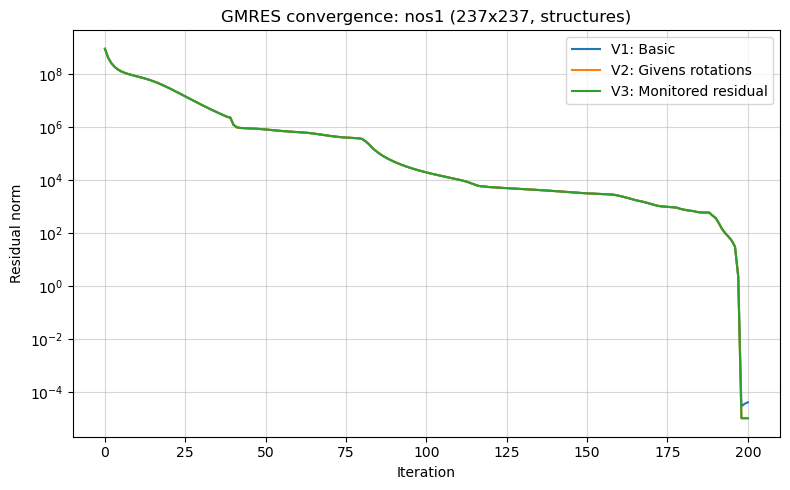


Matrix: sherman1 (1000x1000, oil reservoir)
  Size: 1000x1000, nnz: 3750, max_iter: 200
  V1: Basic: 200 iters, res=3.00e-04, err=8.70e-01, time=1.002s
  V2: Givens rotations: 200 iters, res=3.00e-04, err=8.70e-01, time=0.384s
  V3: Monitored residual: 200 iters, res=3.00e-04, err=8.70e-01, time=0.309s


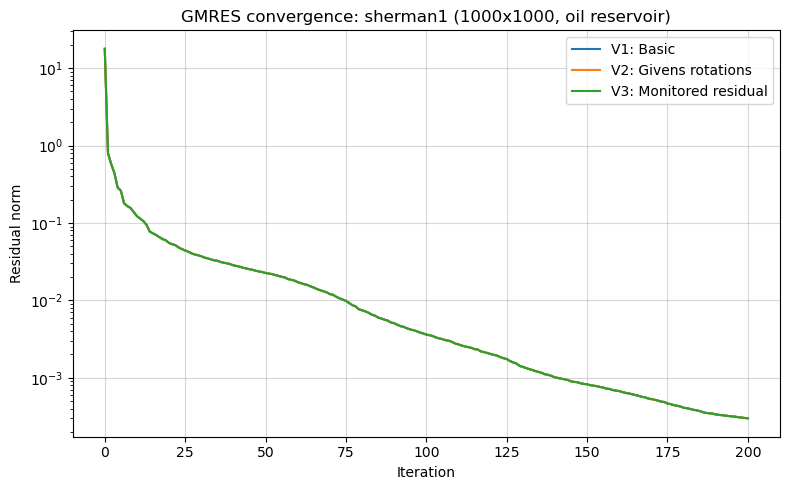


Matrix: orsirr_1 (1030x1030, oil reservoir)
  Size: 1030x1030, nnz: 6858, max_iter: 200
  V1: Basic: 200 iters, res=4.35e+00, err=4.22e-01, time=1.103s
  V2: Givens rotations: 200 iters, res=4.35e+00, err=4.22e-01, time=0.433s
  V3: Monitored residual: 200 iters, res=4.35e+00, err=4.22e-01, time=0.339s


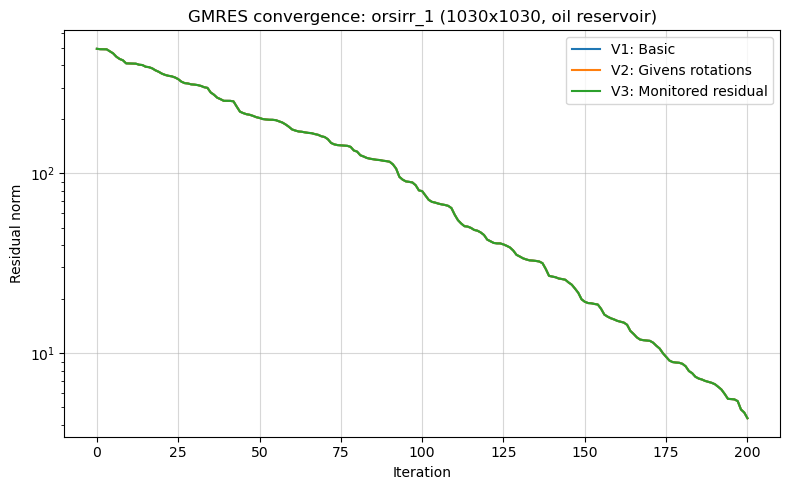


Matrix: west0497 (497x497, chemical eng.)
  Size: 497x497, nnz: 1727, max_iter: 200
  V1: Basic: 200 iters, res=1.87e+03, err=9.21e+03, time=0.745s
  V2: Givens rotations: 200 iters, res=1.87e+03, err=9.21e+03, time=0.267s
  V3: Monitored residual: 200 iters, res=1.87e+03, err=9.21e+03, time=0.242s


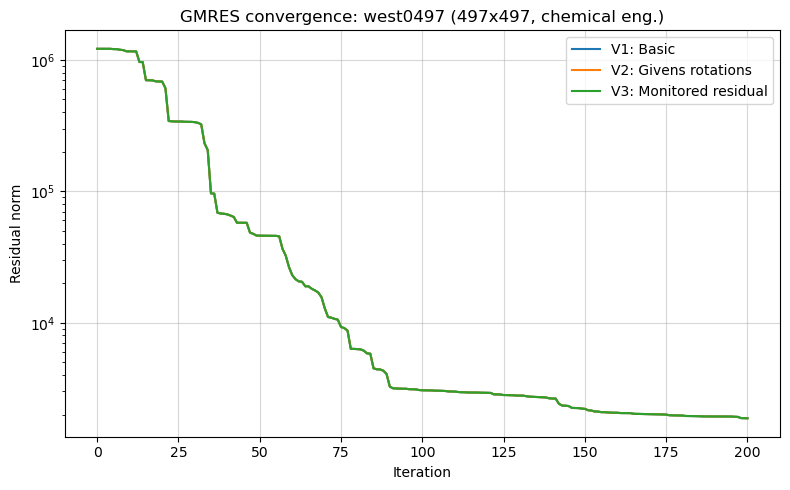


Matrix: fs_541_1 (541x541, frequency response)
  Size: 541x541, nnz: 4285, max_iter: 200
  V1: Basic: 15 iters, res=2.14e-11, err=1.84e-11, time=0.004s
  V2: Givens rotations: 15 iters, res=2.14e-11, err=1.84e-11, time=0.002s
  V3: Monitored residual: 15 iters, res=2.14e-11, err=1.84e-11, time=0.002s


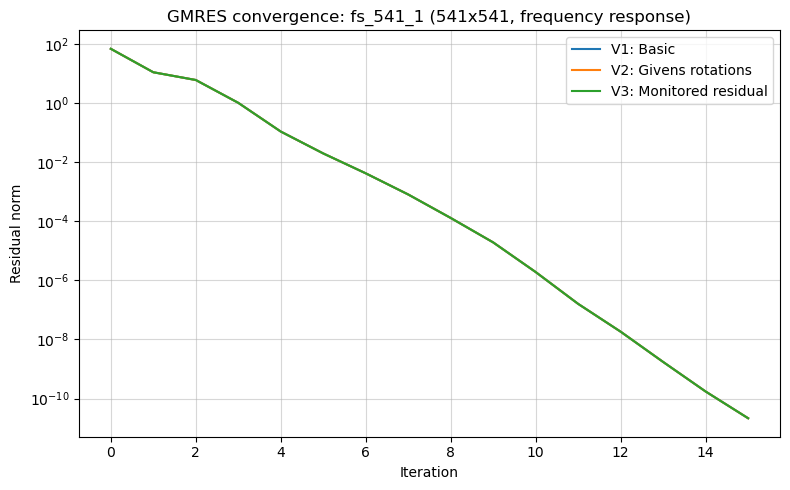

In [5]:
### Downloading a selection of SuiteSparse matrices. These ones are all square and real.
matrix_info = [
    ("HB", "nos1",      "nos1 (237x237, structures)"),
    ("HB", "sherman1",  "sherman1 (1000x1000, oil reservoir)"),
    ("HB", "orsirr_1",  "orsirr_1 (1030x1030, oil reservoir)"),
    ("HB", "west0497",  "west0497 (497x497, chemical eng.)"),
    ("HB", "fs_541_1",  "fs_541_1 (541x541, frequency response)"),
]

# Running all 3 GMRES versions on each matrix
methods = {
    "V1: Basic":      gmres_basic,
    "V2: Givens rotations":    gmres_givens,
    "V3: Monitored residual":  gmres_monitored,
}

for group, name, description in matrix_info:
    print(f"\n{'='*60}")
    print(f"Matrix: {description}")
    print(f"{'='*60}")

    A_sparse = fetch_matrix(group, name)
    if A_sparse is None:
        continue

    n = A_sparse.shape[0]
    A_dense = A_sparse.toarray()

    # Building a right-hand side: b = A @ ones
    x_true = np.ones(n)
    b = A_dense @ x_true

    max_iter = min(n, 200)  # cap iterations for larger matrices

    print(f"  Size: {n}x{n}, nnz: {A_sparse.nnz}, max_iter: {max_iter}")

    fig, ax = plt.subplots(figsize=(8, 5))

    for label, method in methods.items():
        t0 = time.time()
        try:
            x, residuals = method(A_dense, b, np.zeros(n), max_iter=max_iter, tol=1e-10)
            elapsed = time.time() - t0
            error = np.linalg.norm(x - x_true)
            print(f"  {label}: {len(residuals)-1} iters, "
                  f"res={residuals[-1]:.2e}, err={error:.2e}, time={elapsed:.3f}s")
            ax.semilogy(residuals, label=label)
        except Exception as e:
            print(f"  {label}: FAILED — {e}")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Residual norm")
    ax.set_title(f"GMRES convergence: {description}")
    ax.grid(True, alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()